covid

import libraries and csv file

In [31]:
pip install -U scikit-learn

     ---------------------------------------- 0.0/60.6 kB ? eta -:--:--
     ------ --------------------------------- 10.2/60.6 kB ? eta -:--:--
     ---------------------------------------- 60.6/60.6 kB 1.1 MB/s eta 0:00:00
   ---------------------------------------- 0.0/10.6 MB ? eta -:--:--
    --------------------------------------- 0.2/10.6 MB 5.6 MB/s eta 0:00:02
   -- ------------------------------------- 0.6/10.6 MB 7.1 MB/s eta 0:00:02
   ------- -------------------------------- 1.9/10.6 MB 15.0 MB/s eta 0:00:01
   --------- ------------------------------ 2.6/10.6 MB 16.8 MB/s eta 0:00:01
   ----------------- ---------------------- 4.7/10.6 MB 22.9 MB/s eta 0:00:01
   ------------------------- -------------- 6.7/10.6 MB 25.2 MB/s eta 0:00:01
   --------------------------------- ------ 8.8/10.6 MB 28.0 MB/s eta 0:00:01
   ---------------------------------------  10.6/10.6 MB 36.4 MB/s eta 0:00:01
   ---------------------------------------- 10.6/10.6 MB 34.4 MB/s eta 0:00:00
   

In [3]:
#importing libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
#import csv file
covid = pd.read_csv("CovidData/Covid Data.csv")

prepare data

In [5]:
# delete duplicate rows
covid.drop_duplicates(inplace=True)

In [6]:
# delete not used columns
covid.drop(columns=['MEDICAL_UNIT','USMER'], inplace =True)

In [7]:
# rename columns
covid.rename(columns=
             {'PATIENT_TYPE':'HOSPITALIZED',
              'DATE_DIED':'DEAD',
              'INMSUPR': 'IMMUNOSUPPRESSED',
              'CLASIFFICATION_FINAL': 'COVID_TEST_RESULT',
              'TOBACCO': "SMOKER",
              'CARDIOVASCULAR': 'CARDIOVASCULAR_DISEASE',
              'RENAL_CHRONIC': 'CHRONIC_KIDNEY_DISEASE',
              'ICU': 'ADMITTED_TO_ICU'}, inplace=True)

In [8]:
# update columns order
covid = covid.loc[:,
                  ['COVID_TEST_RESULT', 
                   'HOSPITALIZED',
                   'INTUBED',
                   'ADMITTED_TO_ICU',
                   'DEAD',
                   'AGE',
                   'SEX',
                   'PREGNANT',
                   'SMOKER',
                   'PNEUMONIA',
                   'COPD',
                   'ASTHMA',
                   'IMMUNOSUPPRESSED',
                   'CARDIOVASCULAR_DISEASE',
                   'HIPERTENSION',
                   'CHRONIC_KIDNEY_DISEASE',
                   'DIABETES',
                   'OBESITY',
                   'OTHER_DISEASE']]

In [9]:
# column "DEAD" dead: 1, alive: 0
covid['DEAD'] = covid['DEAD'].replace({'9999-99-99': 0})
covid['DEAD'] = covid['DEAD'].apply(lambda x: 1 if x != 0 else 0)

In [10]:
# column "SEX" female: 1, male: 0
covid['SEX'] = covid['SEX'].replace({2:0})

In [11]:
# change 2 for 0 ('False'), 97, 98 and 99 for 0
covid[['INTUBED','ADMITTED_TO_ICU','PREGNANT','SMOKER','PNEUMONIA','COPD','ASTHMA','IMMUNOSUPPRESSED',
       'CARDIOVASCULAR_DISEASE','HIPERTENSION','CHRONIC_KIDNEY_DISEASE', 'DIABETES','OBESITY','OTHER_DISEASE']] = covid[[
           'INTUBED','ADMITTED_TO_ICU','PREGNANT','SMOKER','PNEUMONIA','COPD','ASTHMA','IMMUNOSUPPRESSED',
           'CARDIOVASCULAR_DISEASE','HIPERTENSION', 'CHRONIC_KIDNEY_DISEASE','DIABETES','OBESITY','OTHER_DISEASE']].replace({2: 0, 97: 0, 98: 0, 99: 0})

In [12]:
#change column "HOSPITALIZED" to 0,1 format
covid['HOSPITALIZED'] = covid['HOSPITALIZED'].replace({1: 0, 2: 1})

In [13]:
#update column "COVID_TEST_RESULT" to 0,1 format
covid['COVID_TEST_RESULT'] = covid['COVID_TEST_RESULT'].apply(lambda x: 1 if x in [1,2,3] else 0)

In [14]:
#function creating a values for age group
def grouping_age(row) -> str:
    if row['AGE'] < 18:
        val = '-18'
    elif row['AGE'] < 30:
        val = '18-30'
    elif row['AGE'] < 45:
        val = '30-45'
    elif row['AGE'] < 60:
        val = '45-60'
    else:
        val = '60+'
    return val

In [15]:
#create column "AGE_GROUP"
covid["AGE_GROUP"] = covid.apply(grouping_age, axis=1)

In [16]:
#move column "AGE_GROUP" next to "AGE" column
column_to_move = covid.pop('AGE_GROUP')
covid.insert(6, "AGE_GROUP", column_to_move)

In [57]:
#create a table grouped by age and aggregated as sum
covid_age = covid.groupby("AGE_GROUP").sum()

In [58]:
covid_age

,COVID_TEST_RESULT,HOSPITALIZED,INTUBED,ADMITTED_TO_ICU,DEAD,AGE,SEX,PREGNANT,SMOKER,PNEUMONIA,COPD,ASTHMA,IMMUNOSUPPRESSED,CARDIOVASCULAR_DISEASE,HIPERTENSION,CHRONIC_KIDNEY_DISEASE,DIABETES,OBESITY,OTHER_DISEASE
AGE_GROUP,,,,,,,,,,,,,,,,,,,
-18,2198,5190,899,930,802,81093,4978,143,239,2535,78,1172,1170,636,299,298,300,916,1695
18-30,6507,6516,951,775,1377,471186,10001,1452,3625,4421,301,2387,1188,831,2559,1297,1792,4837,1880
30-45,19994,19864,3883,2385,7644,1752941,21825,1357,8419,15089,1113,4750,2633,2348,11236,2915,9603,15555,4121
45-60,35475,39947,10370,4772,23014,3618935,30350,52,9509,30365,3026,4637,3403,4489,26773,5062,24899,22238,5335
60+,49114,65127,16192,6521,43128,6521908,39869,16,10833,47320,9551,3090,3896,9607,47138,7532,37162,19782,6549


charts

C:\Users\bartb\AppData\Local\Temp\ipykernel_13348\2512485428.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x="AGE_GROUP", y="COVID_TEST_RESULT", estimator="sum", data=covid_age, palette="YlGnBu")


[Text(0.5, 0, 'grupa wiekowa'), Text(0, 0.5, 'ilość z pozytywnym testem')]

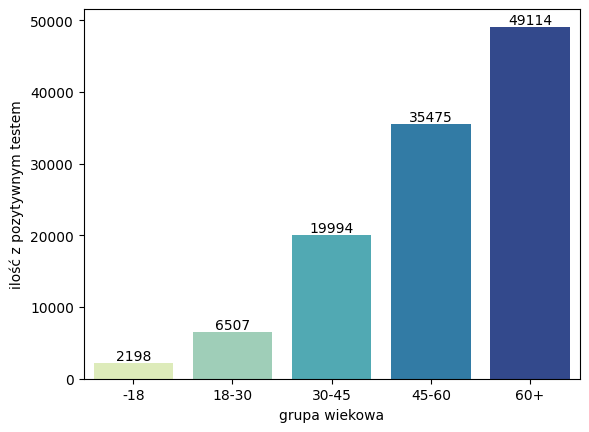

In [19]:
#sum of positive covid test in each age group
ax = sns.barplot(x="AGE_GROUP", y="COVID_TEST_RESULT", estimator="sum", data=covid_age, palette="YlGnBu")
for container in ax.containers:
    ax.bar_label(container)
ax.set(xlabel="grupa wiekowa", ylabel="ilość z pozytywnym testem")

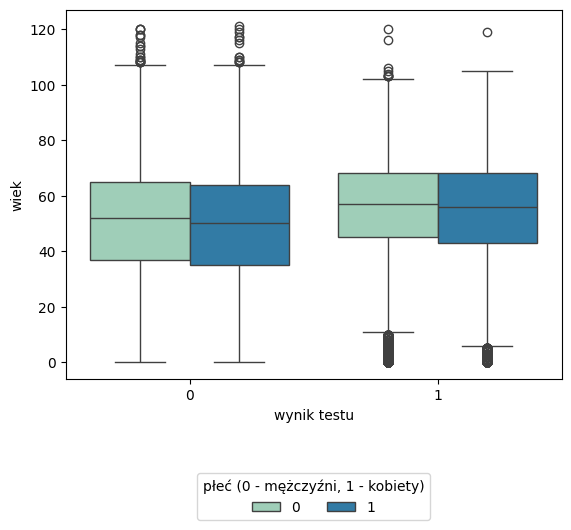

In [20]:
#median and quartiles
ax = sns.boxplot(x="COVID_TEST_RESULT", y="AGE", data=covid, hue="SEX", palette="YlGnBu")
ax.set(xlabel="wynik testu", ylabel="wiek")
sns.move_legend(ax, "lower center", bbox_to_anchor=(0.5, -0.4), ncol=2, title="płeć (0 - mężczyźni, 1 - kobiety)", frameon=True)

In [21]:
#create a table with column's values 0,1
covid_sick = covid[['COVID_TEST_RESULT','HOSPITALIZED','INTUBED','ADMITTED_TO_ICU','DEAD','AGE','SEX','PREGNANT','SMOKER','PNEUMONIA','COPD','ASTHMA','IMMUNOSUPPRESSED','CARDIOVASCULAR_DISEASE','HIPERTENSION','CHRONIC_KIDNEY_DISEASE', 'DIABETES','OBESITY','OTHER_DISEASE']]

In [22]:
#only positive covid patients
covid_sick = covid_sick.loc[(covid_sick['COVID_TEST_RESULT'] == 1)]

In [24]:
#create a list of conditions to be correlated with death
conditions = ['INTUBED','ADMITTED_TO_ICU', 'AGE','SEX','PREGNANT','SMOKER','PNEUMONIA','COPD','ASTHMA','IMMUNOSUPPRESSED','CARDIOVASCULAR_DISEASE','HIPERTENSION','CHRONIC_KIDNEY_DISEASE', 'DIABETES','OBESITY','OTHER_DISEASE']

korelacja pearsona - zły przykład, bo to dla wartości ciagłych a mamy 0,1

In [25]:
#correlating in for loop and creating a dictionary
death_corrs = {}
for condition in conditions:
    corr = round(covid_sick[condition].corr(covid_sick["DEAD"]),3)
    death_corrs[condition] = corr

In [27]:
#list with sorted correlations
death_corrs = sorted(death_corrs.items(), key=lambda x: x[1], reverse=True)

In [28]:
death_corrs

[('PNEUMONIA', 0.392),
 ('INTUBED', 0.39),
 ('AGE', 0.33),
 ('ADMITTED_TO_ICU', 0.09),
 ('DIABETES', 0.072),
 ('HIPERTENSION', 0.066),
 ('CHRONIC_KIDNEY_DISEASE', 0.006),
 ('COPD', -0.017),
 ('CARDIOVASCULAR_DISEASE', -0.051),
 ('IMMUNOSUPPRESSED', -0.059),
 ('OTHER_DISEASE', -0.059),
 ('OBESITY', -0.078),
 ('PREGNANT', -0.081),
 ('SMOKER', -0.113),
 ('SEX', -0.129),
 ('ASTHMA', -0.139)]

CREATE A LOGISTIC REGRESION MODEL - to będzie dobry przykład, który omawialiśmy z Mateuszem na zajeciach

In [75]:
#split dataset in features (X) and target variable (Y)
#create a list of conditions to be correlated with death
features = ['INTUBED','ADMITTED_TO_ICU', 'AGE','SEX','PREGNANT','SMOKER','PNEUMONIA','COPD','ASTHMA','IMMUNOSUPPRESSED','CARDIOVASCULAR_DISEASE','HIPERTENSION','CHRONIC_KIDNEY_DISEASE', 'DIABETES','OBESITY','OTHER_DISEASE']
X = covid_sick[features] # Features
y = covid_sick["DEAD"] # Target variable

In [113]:
# import the logistic regresion class
from sklearn.linear_model import LogisticRegression

# create the model
model_logreg = LogisticRegression()

# fit the model with data
model_logreg.fit(X, y)

#create prediction
y_pred = model_logreg.predict(X)


c:\Users\bartb\anaconda3\envs\infoshare_virtual_env\Lib\site-packages\sklearn\linear_model\_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


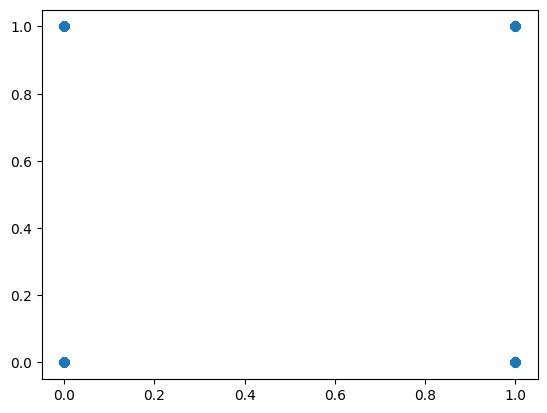

In [107]:
#plot pneumonia vs dead logistic regresion, but without differenciate the size of dots
plt.scatter(covid_sick["PNEUMONIA"], covid_sick["DEAD"])
plt.show
pass

In [50]:
# import the metrics class
from sklearn import metrics

confusion_matrix = metrics.confusion_matrix(y, y_pred)
confusion_matrix

array([[46966, 12974],
       [14791, 38557]], dtype=int64)

Text(0.5, 23.52222222222222, 'PREDICTED_DEAD')

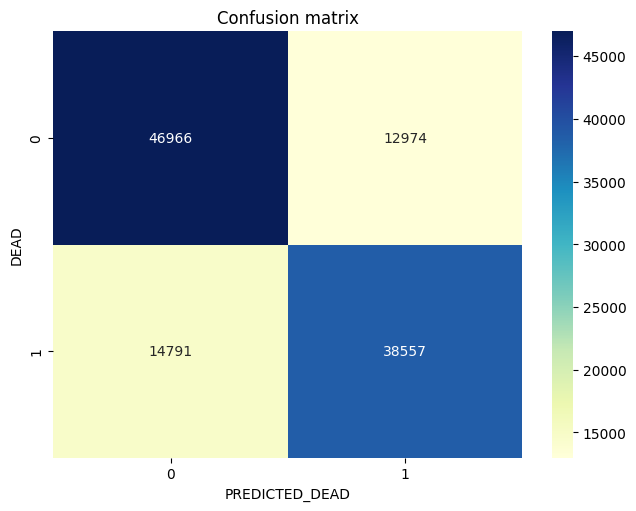

In [82]:
class_names=[0,1] # name  of classes
fig, ax = plt.subplots()
tick_marks = np.arange(len(class_names))
plt.xticks(tick_marks, class_names)
plt.yticks(tick_marks, class_names)
# create heatmap
sns.heatmap(pd.DataFrame(confusion_matrix), annot=True, cmap="YlGnBu" ,fmt='g')
ax.xaxis.set_label_position("bottom")
plt.tight_layout()
plt.title('Confusion matrix')
plt.ylabel('DEAD')
plt.xlabel('PREDICTED_DEAD')


In [83]:
from sklearn.metrics import classification_report

target_names = ['no covid', 'covid']
print(classification_report(y, y_pred, target_names=target_names))

              precision    recall  f1-score   support

    no covid       0.76      0.78      0.77     59940
       covid       0.75      0.72      0.74     53348

    accuracy                           0.75    113288
   macro avg       0.75      0.75      0.75    113288
weighted avg       0.75      0.75      0.75    113288



powyżej - skuteczność (precyzja) modelu to ok 75% - pytanie czy to wystarczająca wartość, czy da się podciągnąć wydajność modelu

In [99]:
#   CREATE A COEFICIENCY ARRAY FOR FEATURES AND DEAD IN LOGISTIC REGRESION
coeficiencies = logreg.coef_

In [111]:
#create keys and values for a dictionary
values = []
for i in coeficiencies[0]:
    exp_coef = np.exp(i)
    values.append(exp_coef)

keys = features

print(keys)
print(values)

['INTUBED', 'ADMITTED_TO_ICU', 'AGE', 'SEX', 'PREGNANT', 'SMOKER', 'PNEUMONIA', 'COPD', 'ASTHMA', 'IMMUNOSUPPRESSED', 'CARDIOVASCULAR_DISEASE', 'HIPERTENSION', 'CHRONIC_KIDNEY_DISEASE', 'DIABETES', 'OBESITY', 'OTHER_DISEASE']
[9.132682815050599, 0.4514421061312601, 1.041207804724888, 0.6138041455276965, 0.3614800498325118, 0.47940583976330575, 3.961402433312058, 0.6839909873701778, 0.40634376338345163, 0.6617843956287944, 0.5726567052092048, 0.960861007139191, 1.153007462025574, 1.0903798402629925, 0.8487780682804891, 0.7626058964890655]


In [112]:
#create a dictionary with results
death_logreg = dict(zip(keys, values))
print(death_logreg)


{'INTUBED': 9.132682815050599, 'ADMITTED_TO_ICU': 0.4514421061312601, 'AGE': 1.041207804724888, 'SEX': 0.6138041455276965, 'PREGNANT': 0.3614800498325118, 'SMOKER': 0.47940583976330575, 'PNEUMONIA': 3.961402433312058, 'COPD': 0.6839909873701778, 'ASTHMA': 0.40634376338345163, 'IMMUNOSUPPRESSED': 0.6617843956287944, 'CARDIOVASCULAR_DISEASE': 0.5726567052092048, 'HIPERTENSION': 0.960861007139191, 'CHRONIC_KIDNEY_DISEASE': 1.153007462025574, 'DIABETES': 1.0903798402629925, 'OBESITY': 0.8487780682804891, 'OTHER_DISEASE': 0.7626058964890655}


na razie to słownik, pozostaje interpretacja z uwzględnieniem, czy korelacja była ujemna czy dodatnia

In [85]:
np.exp(2.2118595)

9.132682837335953

WNIOSEK - jesli pajent byl intubowany to ryzyko zgonu wzrasta x9

In [87]:
np.exp(0.04038139)

1.0412078047204814

WNIOSEK - z każdym rokiem życia pacjenta ryzyko zgonu wzrasta o 4% (YoY)